In [1]:
import numpy as np
from hkan.hkan import (
    ExpandingLayer, ConnectingLayer,
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    set_tqdm_disable,
)
from hkan import swim_sampling as ss
DATA_DIR = "data"

In [2]:
tf1_trn = np.loadtxt(f"{DATA_DIR}/TF1_trn.csv", delimiter=",")
tf1_tst = np.loadtxt(f"{DATA_DIR}/TF1_tst.csv", delimiter=",")

tf1_x_train, tf1_y_train = tf1_trn[:, :-1], tf1_trn[:, -1]
tf1_x_test,  tf1_y_test  = tf1_tst[:, :-1], tf1_tst[:, -1]

print(tf1_x_train.shape, tf1_x_test.shape)

(5000, 2) (10000, 2)


In [3]:
# 1) Generate M candidate pairs using full-D distance (multi-dimensional)
x_a, x_b, y_a, y_b = ss.sample_candidate_pairs(tf1_x_train, tf1_y_train)

In [4]:
# 2) score each candidate pair: |dy| / ||dx|| (full-D distance)
probs = ss.create_swim_probabilities(x_a, x_b, y_a, y_b)

In [5]:
# 3) select ONE winning pair for this output node q (per our final design: 1 pair per q)
random_seed = 1
x_a_sel, x_b_sel, y_a_sel, y_b_sel, selected_idx = ss.select_pairs(
    x_a, x_b, y_a, y_b, probs, layer_width=3, random_seed=random_seed
)

In [6]:
x_a_sel, x_b_sel, y_a_sel, y_b_sel

(array([[0.02691841, 0.86326752],
        [0.20574326, 0.95672679],
        [0.47795066, 0.83256066]]),
 array([[0.80009221, 0.40700227],
        [0.45995135, 0.34494496],
        [0.75651739, 0.59599565]]),
 array([0.15628965, 0.23121013, 0.48533452]),
 array([0.44418421, 0.51241949, 0.54924911]))

In [7]:
q = 0 # the first neuron in the hidden layer
p = 0 # the first dimension

lo = min(x_a_sel[q, p], x_b_sel[q, p])
hi = max(x_a_sel[q, p], x_b_sel[q, p])

print(f"q={q}, p={p}: range=[{lo:.4f}, {hi:.4f}]")

q=0, p=0: range=[0.0269, 0.8001]


In [8]:
# collect local 1D points from the local range
min_points = 5 # threshold for fallback when there is an insufficient number of points in that interval
max_points = 250 # threshold for capping in case of a large number of points in that interval
k_fallback = 10 # default number of points for the insufficient number of points case

x_p = tf1_x_train[:, p]
tf1_x_train, x_p

(array([[0.22686546, 0.75573285],
        [0.39266586, 0.65372895],
        [0.38102344, 0.30110655],
        ...,
        [0.79951458, 0.82069574],
        [0.58831701, 0.40153064],
        [0.59800363, 0.05717482]]),
 array([0.22686546, 0.39266586, 0.38102344, ..., 0.79951458, 0.58831701,
        0.59800363]))

In [9]:
# Create mask
mask = (x_p >= lo) & (x_p <= hi) # returns true, false
n_inside = int(mask.sum())
midpoint = (lo + hi) / 2

In [10]:
n_inside

3835

In [11]:
method = "none"
if n_inside >= min_points:
    x_p_inside, y_p_inside = x_p[mask], tf1_y_train[mask]
    if n_inside <= max_points:
        local_x_p, local_y, method = x_p_inside, y_p_inside, "interval"
    else: 
        # Take the nearest 100 points to the midpoint
        order = np.argsort(np.abs(x_p_inside - midpoint))
        cap_idx = order[:max_points]
        local_x_p, local_y, method = x_p_inside[cap_idx], x_p_inside[cap_idx], "interval_capped"
# Use fallback: the nearest points
else: 
    order = np.argsort(np.abs(x_p - midpoint))
    knn_idx = order[:k_fallback]
    local_x_p, local_y, method = x_p[knn_idx], tf1_y_train[knn_idx], "knn_fallback"

print(f"method={method}, n_inside={n_inside}")
print("local_x shape:", local_x_p.shape)
print("local_y shape:", local_y.shape)

method=interval_capped, n_inside=3835
local_x shape: (250,)
local_y shape: (250,)


In [12]:
# # Median Heuristic (Median Trick)

# num_inducing = 15 # like basis function limitation in HKAN
# sigma_scale = 1
# noise_ratio = 0.1

# n = local_x_p.shape[0]
# num_inducing_eff = min(num_inducing, n) 

# # Create inducing points
# z = np.linspace(local_x_p.min(), local_x_p.max(), num_inducing_eff)
# print("z (inducing points) shape:", z.shape)

In [13]:
num_inducing = 15
sigma_scale = 1
noise_ratio = 0.1

n = local_x_p.shape[0]
num_inducing_eff = min(num_inducing, n)

rng = np.random.default_rng(0)  # reproducibility icin sabit seed
idx = rng.choice(n, size=num_inducing_eff, replace=False)
z = np.sort(local_x_p[idx])   # sort: gorsellestirme/okuma kolayligi icin

print("z (inducing points) shape:", z.shape)

z (inducing points) shape: (15,)


In [14]:
# Calculate pointwise distance (n, n) matrix
diffs = np.abs(local_x_p[:, None] - local_x_p[None, :])
diffs, diffs.shape

(array([[0.00000000e+00, 5.99967750e-05, 5.90405431e-04, ...,
         2.28103037e-02, 2.29912471e-02, 2.31847008e-02],
        [5.99967750e-05, 0.00000000e+00, 6.50402206e-04, ...,
         2.27503070e-02, 2.30512439e-02, 2.32446976e-02],
        [5.90405431e-04, 6.50402206e-04, 0.00000000e+00, ...,
         2.34007092e-02, 2.24008417e-02, 2.25942954e-02],
        ...,
        [2.28103037e-02, 2.27503070e-02, 2.34007092e-02, ...,
         0.00000000e+00, 4.58015509e-02, 4.59950046e-02],
        [2.29912471e-02, 2.30512439e-02, 2.24008417e-02, ...,
         4.58015509e-02, 0.00000000e+00, 1.93453694e-04],
        [2.31847008e-02, 2.32446976e-02, 2.25942954e-02, ...,
         4.59950046e-02, 1.93453694e-04, 0.00000000e+00]]),
 (250, 250))

In [15]:
# exclude diagram
mask_diag = ~np.eye(n, dtype=bool)
# calculate the median of all pairwise distances except the diagonal
lengthscale = sigma_scale * np.median(diffs[mask_diag]) if n > 1 else sigma_scale
# fallback
lengthscale = max(lengthscale, 1e-6)
signal_var = np.var(local_y) + 1e-8 # how much the target values naturally vary across the local points
noise_var = noise_ratio * signal_var # how much of that variation is treated as random
print(f"lengthscale={lengthscale:.5f}, signal_var={signal_var:.5f}, noise_var={noise_var:.7f}")

lengthscale=0.01365, signal_var=0.00018, noise_var=0.0000178


In [16]:
K_mm = signal_var * np.exp(-(z[:, None] - z[None, :])**2 / (2 * lengthscale**2))
K_nm = signal_var * np.exp(-(local_x_p[:, None] - z[None, :])**2 / (2 * lengthscale**2))

print("K_mm shape:", K_mm.shape) 
print("K_nm shape:", K_nm.shape)

K_mm shape: (15, 15)
K_nm shape: (250, 15)


In [17]:
A = K_nm.T @ K_nm + noise_var * K_mm
b = K_nm.T @ local_y
alpha_z = np.linalg.solve(A + 1e-10 * np.eye(num_inducing_eff), b)

print("A shape:", A.shape)        
print("b shape:", b.shape)
print("alpha_z shape:", alpha_z.shape)
print("alpha_z:", np.round(alpha_z, 6))

A shape: (15, 15)
b shape: (15,)
alpha_z shape: (15,)
alpha_z: [ 3787.435781 -2798.415906  -854.60857     -7.19012    609.411548
  1510.912282  1558.755489   699.375182  -600.591834  -823.694205
  -809.532808  -742.91962    137.430721  1335.00764   2210.700824]


In [18]:
x_star = tf1_x_train[:, p] 

k_star = signal_var * np.exp(-(x_star[:, None] - z[None, :])**2 / (2 * lengthscale**2))
edge_output_p0 = k_star @ alpha_z

print("x_star shape:", x_star.shape)
print("k_star shape:", k_star.shape)
print("edge_output_p0 shape:", edge_output_p0.shape)
print("edge_output_p0 ilk 5 deger:", np.round(edge_output_p0[:5], 5))

x_star shape: (5000,)
k_star shape: (5000, 15)
edge_output_p0 shape: (5000,)
edge_output_p0 ilk 5 deger: [0.      0.38876 0.25467 0.      0.     ]


In [19]:
correlation = np.corrcoef(edge_output_p0, tf1_y_train)[0, 1]
print(f"edge_output_p0 ile y arasindaki korelasyon: {correlation:.4f}")

edge_output_p0 ile y arasindaki korelasyon: -0.0195


In [20]:
lo_check = min(x_a_sel[q, p], x_b_sel[q, p])
hi_check = max(x_a_sel[q, p], x_b_sel[q, p])
in_region = (tf1_x_train[:, p] >= lo_check) & (tf1_x_train[:, p] <= hi_check)

correlation_local = np.corrcoef(edge_output_p0[in_region], tf1_y_train[in_region])[0, 1]
print(f"Yerel bolgedeki korelasyon: {correlation_local:.4f}")
print(f"Yerel bolgedeki nokta sayisi: {in_region.sum()} / {len(tf1_y_train)}")

Yerel bolgedeki korelasyon: -0.0238
Yerel bolgedeki nokta sayisi: 3835 / 5000


In [21]:
# local_x, local_y zaten Hucre 8'den (capped) geliyor -- GP'nin GERCEKTEN gordugu bolge
z_lo, z_hi = local_x_p.min(), local_x_p.max()
in_actual_region = (tf1_x_train[:, p] >= z_lo) & (tf1_x_train[:, p] <= z_hi)

correlation_actual = np.corrcoef(edge_output_p0[in_actual_region], tf1_y_train[in_actual_region])[0, 1]
print(f"GP'nin gercekten gordugu bolgedeki korelasyon: {correlation_actual:.4f}")
print(f"O bolgedeki nokta sayisi: {in_actual_region.sum()}")

GP'nin gercekten gordugu bolgedeki korelasyon: 0.1229
O bolgedeki nokta sayisi: 250


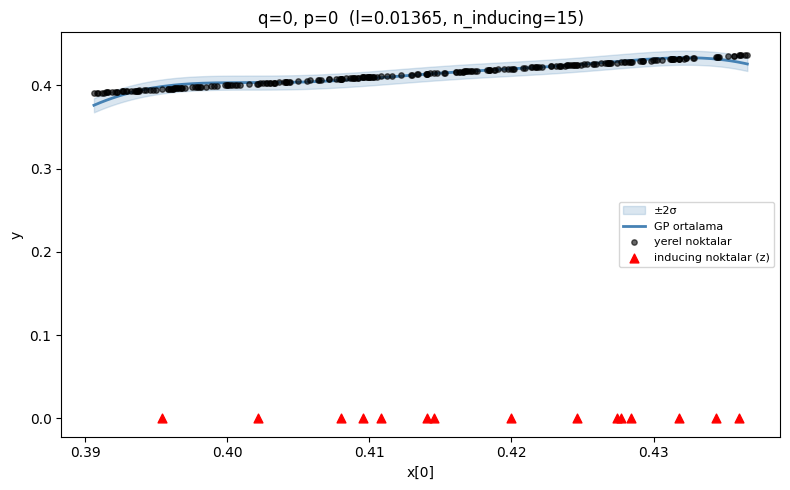

In [22]:
import matplotlib.pyplot as plt

# --- yogun bir x araligi olustur (yerel bolgede) ---
x_dense = np.linspace(local_x_p.min(), local_x_p.max(), 200)

# --- ortalama tahmin (zaten bildigimiz formul) ---
k_dense = signal_var * np.exp(-(x_dense[:, None] - z[None, :])**2 / (2 * lengthscale**2))
mean_dense = k_dense @ alpha_z

# --- belirsizlik bandi icin (opsiyonel ama faydali) ---
K_mm_inv = np.linalg.inv(K_mm + 1e-10 * np.eye(len(z)))
var_dense = signal_var - np.sum((k_dense @ K_mm_inv) * k_dense, axis=1) + noise_var
var_dense = np.clip(var_dense, 0, None)
std_dense = np.sqrt(var_dense)

# --- grafik ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(x_dense, mean_dense - 2*std_dense, mean_dense + 2*std_dense,
                 alpha=0.2, color="steelblue", label="±2σ")
ax.plot(x_dense, mean_dense, color="steelblue", lw=2, label="GP ortalama")
ax.scatter(local_x_p, local_y, color="black", s=15, alpha=0.6, zorder=5,
           label="yerel noktalar")
ax.scatter(z, np.zeros_like(z), color="red", marker="^", s=40, zorder=6,
           label="inducing noktalar (z)")

ax.set_title(f"q={q}, p={p}  (l={lengthscale:.5f}, n_inducing={len(z)})")
ax.set_xlabel(f"x[{p}]")
ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
x_a_sel, x_b_sel

(array([[0.02691841, 0.86326752],
        [0.20574326, 0.95672679],
        [0.47795066, 0.83256066]]),
 array([[0.80009221, 0.40700227],
        [0.45995135, 0.34494496],
        [0.75651739, 0.59599565]]))

In [24]:
p = 1

lo = min(x_a_sel[q, p], x_b_sel[q, p])
hi = max(x_a_sel[q, p], x_b_sel[q, p])

print(f"q={q}, p={p}: aralik=[{lo:.4f}, {hi:.4f}]")

q=0, p=1: aralik=[0.4070, 0.8633]


In [25]:
x_p = tf1_x_train[:, p]
mask = (x_p >= lo) & (x_p <= hi)
n_inside = int(mask.sum())
midpoint = (lo + hi) / 2

if n_inside >= min_points:
    x_inside, y_inside = x_p[mask], tf1_y_train[mask]
    if n_inside <= max_points:
        local_x_p, local_y, method = x_inside, y_inside, "interval"
    else:
        order = np.argsort(np.abs(x_inside - midpoint))
        cap_idx = order[:max_points]
        local_x_p, local_y, method = x_inside[cap_idx], y_inside[cap_idx], "interval_capped"
else:
    order = np.argsort(np.abs(x_p - midpoint))
    knn_idx = order[:k_fallback]
    local_x_p, local_y, method = x_p[knn_idx], tf1_y_train[knn_idx], "knn_fallback"

print(f"method={method}, n_inside={n_inside}")
print("local_x_p shape:", local_x_p.shape)
print("local_y shape:", local_y.shape)

method=interval_capped, n_inside=2321
local_x_p shape: (250,)
local_y shape: (250,)


In [26]:
num_inducing = 15
sigma_scale = 1
noise_ratio = 0.1

n = local_x_p.shape[0]
num_inducing_eff = min(num_inducing, n)

rng = np.random.default_rng(0)
idx = rng.choice(n, size=num_inducing_eff, replace=False)
z = np.sort(local_x_p[idx])

diffs = np.abs(local_x_p[:, None] - local_x_p[None, :])
mask_diag = ~np.eye(n, dtype=bool)
lengthscale = sigma_scale * np.median(diffs[mask_diag]) if n > 1 else sigma_scale
lengthscale = max(lengthscale, 1e-6)

signal_var = np.var(local_y) + 1e-8
noise_var = noise_ratio * signal_var

print(f"lengthscale={lengthscale:.5f}, signal_var={signal_var:.5f}, noise_var={noise_var:.7f}")
print("z shape:", z.shape)

lengthscale=0.01542, signal_var=0.00607, noise_var=0.0006071
z shape: (15,)


In [27]:
K_mm = signal_var * np.exp(-(z[:, None] - z[None, :])**2 / (2 * lengthscale**2))
K_nm = signal_var * np.exp(-(local_x_p[:, None] - z[None, :])**2 / (2 * lengthscale**2))

A = K_nm.T @ K_nm + noise_var * K_mm
b = K_nm.T @ local_y
alpha_z = np.linalg.solve(A + 1e-10 * np.eye(num_inducing_eff), b)

print("K_mm shape:", K_mm.shape)
print("K_nm shape:", K_nm.shape)
print("alpha_z shape:", alpha_z.shape)

cond_number = np.linalg.cond(A)
print(f"A kosul sayisi: {cond_number:.2e}")

K_mm shape: (15, 15)
K_nm shape: (250, 15)
alpha_z shape: (15,)
A kosul sayisi: 7.40e+16


In [28]:
x_star = tf1_x_train[:, p]
k_star = signal_var * np.exp(-(x_star[:, None] - z[None, :])**2 / (2 * lengthscale**2))
edge_output_p1 = k_star @ alpha_z

print("edge_output_p1 shape:", edge_output_p1.shape)
print("edge_output_p1 ilk 5 deger:", np.round(edge_output_p1[:5], 5))

edge_output_p1 shape: (5000,)
edge_output_p1 ilk 5 deger: [0.      0.51868 0.      0.      0.09481]


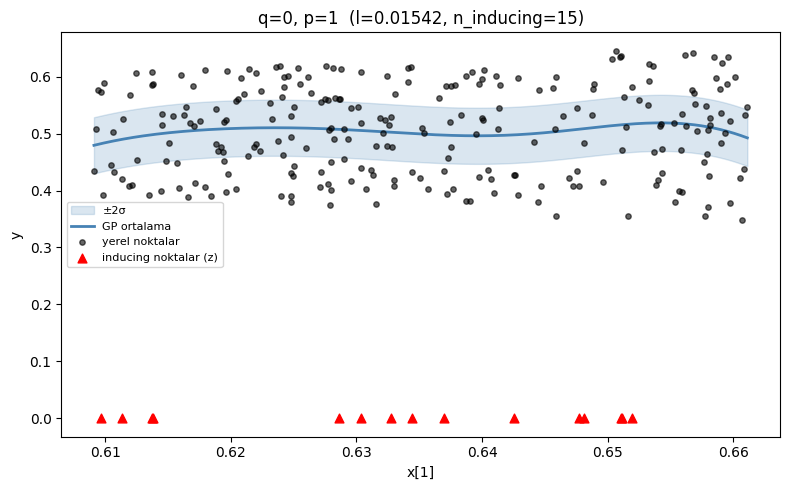

In [29]:
x_dense = np.linspace(local_x_p.min(), local_x_p.max(), 200)
k_dense = signal_var * np.exp(-(x_dense[:, None] - z[None, :])**2 / (2 * lengthscale**2))
mean_dense = k_dense @ alpha_z

K_mm_inv = np.linalg.inv(K_mm + 1e-10 * np.eye(len(z)))
var_dense = signal_var - np.sum((k_dense @ K_mm_inv) * k_dense, axis=1) + noise_var
var_dense = np.clip(var_dense, 0, None)
std_dense = np.sqrt(var_dense)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(x_dense, mean_dense - 2*std_dense, mean_dense + 2*std_dense,
                 alpha=0.2, color="steelblue", label="±2σ")
ax.plot(x_dense, mean_dense, color="steelblue", lw=2, label="GP ortalama")
ax.scatter(local_x_p, local_y, color="black", s=15, alpha=0.6, zorder=5,
           label="yerel noktalar")
ax.scatter(z, np.zeros_like(z), color="red", marker="^", s=40, zorder=6,
           label="inducing noktalar (z)")
ax.set_title(f"q={q}, p={p}  (l={lengthscale:.5f}, n_inducing={len(z)})")
ax.set_xlabel(f"x[{p}]")
ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [30]:
D = tf1_x_train.shape[1]
edge_outputs_q0 = np.column_stack([edge_output_p0, edge_output_p1])   # (M, D)

design = np.column_stack([edge_outputs_q0, np.ones(len(tf1_y_train))])
w_q0, *_ = np.linalg.lstsq(design, tf1_y_train, rcond=None)

h_q0 = design @ w_q0

print("edge_outputs_q0 shape:", edge_outputs_q0.shape)
print("design shape:", design.shape)
print("w_q0 shape:", w_q0.shape)
print("w_q0:", np.round(w_q0, 5))

rmse_q0 = np.sqrt(np.mean((h_q0 - tf1_y_train)**2))
print(f"Noron q=0'in RMSE'si: {rmse_q0:.5f}")
print(f"y'nin std'si (karsilastirma icin): {tf1_y_train.std():.5f}")

edge_outputs_q0 shape: (5000, 2)
design shape: (5000, 3)
w_q0 shape: (3,)
w_q0: [-0.03131 -0.00304  0.50652]
Noron q=0'in RMSE'si: 0.16629
y'nin std'si (karsilastirma icin): 0.16632


In [31]:
def fit_and_predict(p, local_x_p, local_y, num_inducing=15, sigma_scale=1, noise_ratio=0.1, seed=0):
    """
    Bir boyut (p) icin, yerel noktalardan (inducing points ile) GP kurar
    ve TUM egitim setindeki bu boyuttaki kenar ciktisini (edge output) dondurur.
    """
    n = local_x_p.shape[0]
    n_ind = min(num_inducing, n)

    # inducing noktalari veriden rastgele sec
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=n_ind, replace=False)
    z_p = np.sort(local_x_p[idx])

    # lengthscale: medyan sezgisi (median heuristic)
    diffs = np.abs(local_x_p[:, None] - local_x_p[None, :])
    mask_diag = ~np.eye(n, dtype=bool)
    l_p = sigma_scale * np.median(diffs[mask_diag]) if n > 1 else sigma_scale
    l_p = max(l_p, 1e-6)

    # signal / noise variance
    s2_p = np.var(local_y) + 1e-8
    sn2_p = noise_ratio * s2_p

    # kernel matrisleri (inducing-point / sparse GP)
    K_mm = s2_p * np.exp(-(z_p[:, None] - z_p[None, :])**2 / (2 * l_p**2))
    K_nm = s2_p * np.exp(-(local_x_p[:, None] - z_p[None, :])**2 / (2 * l_p**2))

    # dogrusal sistemi coz (alpha_z)
    A = K_nm.T @ K_nm + sn2_p * K_mm
    b = K_nm.T @ local_y
    alpha_p = np.linalg.solve(A + 1e-10 * np.eye(n_ind), b)

    # TUM egitim setinde bu kenari degerlendir
    x_star = tf1_x_train[:, p]
    k_star = s2_p * np.exp(-(x_star[:, None] - z_p[None, :])**2 / (2 * l_p**2))
    edge_output = k_star @ alpha_p

    return edge_output

In [32]:
def collect_local(p, lo, hi, max_points_test=1000):
    """
    Bir boyut (p) icin [lo, hi] araligina dusen egitim noktalarini toplar.
    Cok azsa (knn_fallback) en yakin komsulara, cok fazlaysa (interval_capped)
    midpoint'e en yakin max_points_test taneye duser.
    """
    x_p = tf1_x_train[:, p]
    mask = (x_p >= lo) & (x_p <= hi)
    n_inside = int(mask.sum())
    midpoint = (lo + hi) / 2

    if n_inside >= min_points:
        x_inside, y_inside = x_p[mask], tf1_y_train[mask]
        if n_inside <= max_points_test:
            return x_inside, y_inside, "interval"
        order = np.argsort(np.abs(x_inside - midpoint))
        cap_idx = order[:max_points_test]
        return x_inside[cap_idx], y_inside[cap_idx], "interval_capped"

    order = np.argsort(np.abs(x_p - midpoint))
    knn_idx = order[:k_fallback]
    return x_p[knn_idx], tf1_y_train[knn_idx], "knn_fallback"

def run_neuron(q):
    edge_outs = []
    for p in range(D):
        lo = min(x_a_sel[q, p], x_b_sel[q, p])
        hi = max(x_a_sel[q, p], x_b_sel[q, p])
        local_x_p, local_y, _ = collect_local(p, lo, hi)
        edge_outs.append(fit_and_predict(p, local_x_p, local_y, seed=q))  # seed=q: her noron farkli rastgelelik
    return np.column_stack(edge_outs)  # (M, D)

D = tf1_x_train.shape[1]
layer_width = 3

all_h = []
for q in range(layer_width):
    edge_outputs_q = run_neuron(q)
    design_q = np.column_stack([edge_outputs_q, np.ones(len(tf1_y_train))])
    w_q, *_ = np.linalg.lstsq(design_q, tf1_y_train, rcond=None)
    h_q = design_q @ w_q
    all_h.append(h_q)
    rmse_q = np.sqrt(np.mean((h_q - tf1_y_train)**2))
    print(f"q={q}: RMSE={rmse_q:.5f}")

H = np.column_stack(all_h)  # (M, layer_width) -- katmanin ciktisi

# ikinci asama: bu 3 norani tekrar birlestir
design_final = np.column_stack([H, np.ones(len(tf1_y_train))])
w_final, *_ = np.linalg.lstsq(design_final, tf1_y_train, rcond=None)
y_pred_final = design_final @ w_final

rmse_final = np.sqrt(np.mean((y_pred_final - tf1_y_train)**2))
print(f"\n3 noronu birlestirdikten sonra RMSE: {rmse_final:.5f}")
print(f"y std: {tf1_y_train.std():.5f}")

q=0: RMSE=0.16622
q=1: RMSE=0.16624
q=2: RMSE=0.16627

3 noronu birlestirdikten sonra RMSE: 0.16620
y std: 0.16632


In [33]:
# Her kenarin, TUM veri uzayinda ne kadar "kapsama" sagladigina bakalim
for q in range(layer_width):
    edge_outputs_q = run_neuron(q)
    for p in range(D):
        nonzero_frac = np.mean(np.abs(edge_outputs_q[:, p]) > 1e-3)
        print(f"q={q}, p={p}: |edge output| > 1e-3 olan nokta orani = {nonzero_frac:.3f}")

q=0, p=0: |edge output| > 1e-3 olan nokta orani = 0.633
q=0, p=1: |edge output| > 1e-3 olan nokta orani = 0.626
q=1, p=0: |edge output| > 1e-3 olan nokta orani = 0.588
q=1, p=1: |edge output| > 1e-3 olan nokta orani = 0.614
q=2, p=0: |edge output| > 1e-3 olan nokta orani = 0.623
q=2, p=1: |edge output| > 1e-3 olan nokta orani = 0.601


In [34]:
for p in range(D):
    corr = np.corrcoef(tf1_x_train[:, p], tf1_y_train)[0, 1]
    print(f"x[{p}] ile y arasindaki HAM korelasyon: {corr:.4f}")

# Ayrica coklu dogrusal regresyon (tum boyutlari birden kullanarak) ne kadar aciklıyor:
design_raw = np.column_stack([tf1_x_train, np.ones(len(tf1_y_train))])
w_raw, *_ = np.linalg.lstsq(design_raw, tf1_y_train, rcond=None)
pred_raw = design_raw @ w_raw
rmse_raw = np.sqrt(np.mean((pred_raw - tf1_y_train)**2))
print(f"\nTum boyutlarla DUZ dogrusal regresyon RMSE: {rmse_raw:.5f}")
print(f"y std: {tf1_y_train.std():.5f}")

x[0] ile y arasindaki HAM korelasyon: -0.0107
x[1] ile y arasindaki HAM korelasyon: 0.0175

Tum boyutlarla DUZ dogrusal regresyon RMSE: 0.16629
y std: 0.16632


In [35]:
interaction_feature = tf1_x_train[:, 0] * tf1_x_train[:, 1]
corr_interaction = np.corrcoef(interaction_feature, tf1_y_train)[0, 1]
print(f"x[0]*x[1] (etkilesim) ile y arasindaki korelasyon: {corr_interaction:.4f}")

# ya da dogrusal + etkilesim terimi ile regresyon
design_interact = np.column_stack([tf1_x_train, interaction_feature, np.ones(len(tf1_y_train))])
w_int, *_ = np.linalg.lstsq(design_interact, tf1_y_train, rcond=None)
pred_int = design_interact @ w_int
rmse_int = np.sqrt(np.mean((pred_int - tf1_y_train)**2))
print(f"Etkilesim terimi eklenince RMSE: {rmse_int:.5f}")

x[0]*x[1] (etkilesim) ile y arasindaki korelasyon: 0.3758
Etkilesim terimi eklenince RMSE: 0.00000


In [36]:
def collect_local_gen(X, y, p, lo, hi, min_points=5, max_points=1000, k_fallback=10):
    x_p = X[:, p]
    mask = (x_p >= lo) & (x_p <= hi)
    n_inside = int(mask.sum())
    midpoint = (lo + hi) / 2

    if n_inside >= min_points:
        x_inside, y_inside = x_p[mask], y[mask]
        if n_inside <= max_points:
            return x_inside, y_inside, "interval"
        order = np.argsort(np.abs(x_inside - midpoint))
        cap_idx = order[:max_points]
        return x_inside[cap_idx], y_inside[cap_idx], "interval_capped"

    order = np.argsort(np.abs(x_p - midpoint))
    knn_idx = order[:k_fallback]
    return x_p[knn_idx], y[knn_idx], "knn_fallback"


def fit_and_predict_gen(X, p, local_x_p, local_y, num_inducing=15,
                         sigma_scale=1, noise_ratio=0.1, seed=0):
    n = local_x_p.shape[0]
    n_ind = min(num_inducing, n)

    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=n_ind, replace=False)
    z_p = np.sort(local_x_p[idx])

    diffs = np.abs(local_x_p[:, None] - local_x_p[None, :])
    mask_diag = ~np.eye(n, dtype=bool)
    l_p = sigma_scale * np.median(diffs[mask_diag]) if n > 1 else sigma_scale
    l_p = max(l_p, 1e-6)

    s2_p = np.var(local_y) + 1e-8
    sn2_p = noise_ratio * s2_p

    K_mm = s2_p * np.exp(-(z_p[:, None] - z_p[None, :])**2 / (2 * l_p**2))
    K_nm = s2_p * np.exp(-(local_x_p[:, None] - z_p[None, :])**2 / (2 * l_p**2))

    A = K_nm.T @ K_nm + sn2_p * K_mm
    b = K_nm.T @ local_y
    alpha_p = np.linalg.solve(A + 1e-10 * np.eye(n_ind), b)

    x_star = X[:, p]
    k_star = s2_p * np.exp(-(x_star[:, None] - z_p[None, :])**2 / (2 * l_p**2))
    return k_star @ alpha_p


def select_pairs_gen(X, y, layer_width, random_seed=None, n_candidates=2000):
    M = X.shape[0]
    rng = np.random.default_rng(random_seed)

    idx_a = rng.integers(0, M, size=n_candidates)
    idx_b = rng.integers(0, M, size=n_candidates)

    x_a_cand, x_b_cand = X[idx_a], X[idx_b]
    y_a_cand, y_b_cand = y[idx_a], y[idx_b]

    dist = np.linalg.norm(x_a_cand - x_b_cand, axis=1)
    dist = np.maximum(dist, 1e-8)
    score = np.abs(y_a_cand - y_b_cand) / dist
    probs = score / score.sum()

    selected_idx = rng.choice(n_candidates, size=layer_width, replace=False, p=probs)
    return x_a_cand[selected_idx], x_b_cand[selected_idx]

In [37]:
from sklearn.linear_model import Ridge

def ridge_solve_sklearn(X, y, lam=1.0):
    """
    sklearn Ridge ile kapali-form cozum.
    X: (n, n_features) -- bias sutunu EKLEMEYIN, Ridge kendi ekliyor (fit_intercept=True)
    """
    model = Ridge(alpha=lam, fit_intercept=True)
    model.fit(X, y)
    return model

def run_layer(X, y, layer_width, num_inducing=15, seed=0, ridge_lambda=1.0):
    D_in = X.shape[1]
    x_a, x_b = select_pairs_gen(X, y, layer_width, random_seed=seed)

    H = np.zeros((len(y), layer_width))
    models = []   # artik w_list yerine, egitilmis Ridge modellerini saklıyoruz

    for q in range(layer_width):
        edge_outs = []
        for p in range(D_in):
            lo = min(x_a[q, p], x_b[q, p])
            hi = max(x_a[q, p], x_b[q, p])
            local_x_p, local_y, _ = collect_local_gen(X, y, p, lo, hi)
            edge_out = fit_and_predict_gen(X, p, local_x_p, local_y,
                                             num_inducing=num_inducing, seed=seed + q)
            edge_outs.append(edge_out)

        edge_outputs_q = np.column_stack(edge_outs)   # (M, D_in) -- BIAS SUTUNU YOK ARTIK

        model_q = Ridge(alpha=ridge_lambda, fit_intercept=True)
        model_q.fit(edge_outputs_q, y)

        H[:, q] = model_q.predict(edge_outputs_q)
        models.append(model_q)

    return H, models

In [38]:
from sklearn.linear_model import Ridge

layer_width_1 = 932   # ilk katmanda cok daha fazla noron (ensemble icin)
layer_width_2 = 1     # ikinci katman
ridge_lambda = 0.001

# --- Katman 1: girdi = tf1_x_train, hedef = tf1_y_train ---
H1, models1 = run_layer(tf1_x_train, tf1_y_train, layer_width_1, seed=0, ridge_lambda=ridge_lambda)
print("H1 shape:", H1.shape)   # (M, layer_width_1)

# --- Katman 2: girdi = H1 (katman 1'in ciktisi), hedef = tf1_y_train ---
H2, models2 = run_layer(H1, tf1_y_train, layer_width_2, seed=100, ridge_lambda=ridge_lambda)
print("H2 shape:", H2.shape)   # (M, layer_width_2)

# --- Final: H2'yi RIDGE ile skaler y'ye indir (artik OLS degil) ---
model_final = Ridge(alpha=ridge_lambda, fit_intercept=True)
model_final.fit(H2, tf1_y_train)
y_pred_final = model_final.predict(H2)

rmse_final = np.sqrt(np.mean((y_pred_final - tf1_y_train)**2))
print(f"\n2 katmanli SGKAN (tamamen Ridge) RMSE: {rmse_final:.5f}")
print(f"y std: {tf1_y_train.std():.5f}")

H1 shape: (5000, 932)
H2 shape: (5000, 1)

2 katmanli SGKAN (tamamen Ridge) RMSE: 0.01754
y std: 0.16632


In [39]:
model_final = Ridge(alpha=0.001, fit_intercept=True)
model_final.fit(H2, tf1_y_train)
y_pred_final = model_final.predict(H2)

rmse_final = np.sqrt(np.mean((y_pred_final - tf1_y_train)**2))
print(f"Ridge (sklearn) ile 2 katmanli SGKAN RMSE: {rmse_final:.5f}")
print(f"y std: {tf1_y_train.std():.5f}")

Ridge (sklearn) ile 2 katmanli SGKAN RMSE: 0.01754
y std: 0.16632


In [44]:
def fit_and_predict_basis_only(X, p, local_x_p, num_inducing=15, sigma_scale=1, seed=0):
    n = local_x_p.shape[0]
    n_ind = min(num_inducing, n)

    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=n_ind, replace=False)
    z_p = np.sort(local_x_p[idx])

    diffs = np.abs(local_x_p[:, None] - local_x_p[None, :])
    mask_diag = ~np.eye(n, dtype=bool)
    l_p = sigma_scale * np.median(diffs[mask_diag]) if n > 1 else sigma_scale
    l_p = max(l_p, 1e-6)

    x_star = X[:, p]
    k_star = np.exp(-(x_star[:, None] - z_p[None, :])**2 / (2 * l_p**2))  # (M, n_inducing)
    return k_star


def run_layer_basis(X, y, layer_width, num_inducing=150, seed=0, alpha=1.0, sigma_scale=1.0):
    D_in = X.shape[1]
    x_a, x_b = select_pairs_gen(X, y, layer_width, random_seed=seed)

    H = np.zeros((len(y), layer_width))
    models = []

    for q in range(layer_width):
        feature_blocks = []
        for p in range(D_in):
            lo = min(x_a[q, p], x_b[q, p])
            hi = max(x_a[q, p], x_b[q, p])
            local_x_p, local_y, _ = collect_local_gen(X, y, p, lo, hi)
            k_feat = fit_and_predict_basis_only(X, p, local_x_p,
                                                  num_inducing=num_inducing,
                                                  sigma_scale=sigma_scale, seed=seed + q)
            feature_blocks.append(k_feat)

        all_features = np.column_stack(feature_blocks)   # (M, D_in * n_inducing)

        model_q = Ridge(alpha=alpha, fit_intercept=True)
        model_q.fit(all_features, y)

        H[:, q] = model_q.predict(all_features)
        models.append(model_q)

    return H, models


# --- Calistirma ---
layer_width_1 = 500
layer_width_2 = 1

H1, _ = run_layer_basis(tf1_x_train, tf1_y_train, layer_width_1, seed=0, alpha=1e-3)
H2, _ = run_layer_basis(H1, tf1_y_train, layer_width_2, seed=100, alpha=1e-3)

model_final = Ridge(alpha=1e-3, fit_intercept=True)
model_final.fit(H2, tf1_y_train)
y_pred_final = model_final.predict(H2)

rmse_final = np.sqrt(np.mean((y_pred_final - tf1_y_train)**2))
print(f"Basis-only + Ridge RMSE: {rmse_final:.8f}")
print(f"y std: {tf1_y_train.std():.5f}")

Basis-only + Ridge RMSE: 0.00596818
y std: 0.16632
